# Laboratory Experiment # 005: Data Transmission Modes, Standards, and Protocols

## 1. Multiple Access Protocols 📡
Multiple access schemes define how multiple devices share a single communication channel without stepping on each other's toes.

* **FDMA (Frequency Division):** Everyone gets their own frequency band (like radio stations).
* **TDMA (Time Division):** Everyone takes turns transmitting in specific time slots.
* **CDMA (Code Division):** Everyone transmits at the same time, but using unique mathematical codes.
* **CSMA/CD (Carrier Sense Multiple Access with Collision Detection):** Devices listen before talking. If two talk at once (a collision), they back off for a random time before trying again.

### 1.1 FDMA (Frequency Division Multiple Access) 📻
Instead of splitting by time, FDMA splits the communication channel by frequency. Every device gets its own dedicated frequency band to transmit on constantly, with "guard bands" in between to prevent interference.

In [1]:
# Simulating a basic FDMA frequency allocation table
import pandas as pd

total_bandwidth = 100 # MHz
devices = ['Device_A', 'Device_B', 'Device_C', 'Device_D']
band_per_device = 20 # MHz
guard_band = 5 # MHz

fdma_spectrum = []
current_freq = 0

for device in devices:
    start_freq = current_freq
    end_freq = current_freq + band_per_device
    fdma_spectrum.append({'Device': device, 'Band (MHz)': f"{start_freq} - {end_freq}"})
    # Add guard band before the next device
    current_freq = end_freq + guard_band

print("FDMA Frequency Allocation:")
display(pd.DataFrame(fdma_spectrum))

FDMA Frequency Allocation:


,Device,Band (MHz)
0,Device_A,0 - 20
1,Device_B,25 - 45
2,Device_C,50 - 70
3,Device_D,75 - 95


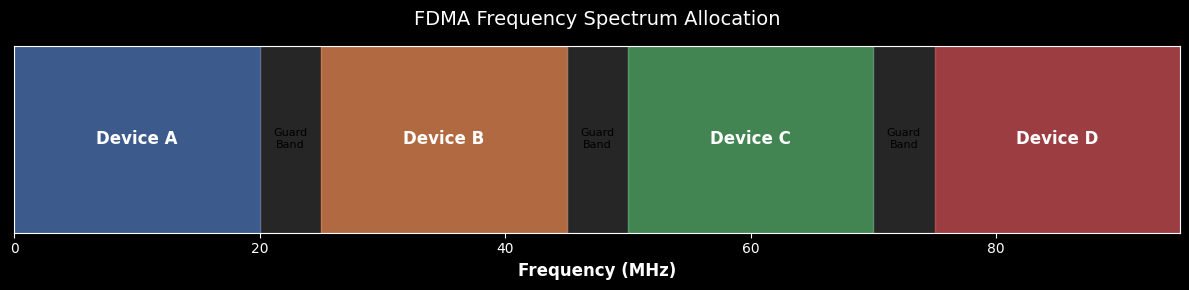

In [2]:
import matplotlib.pyplot as plt

# Set up the figure
fig, ax = plt.subplots(figsize=(12, 3))

# Data from our previous FDMA setup
devices = ['Device A', 'Device B', 'Device C', 'Device D']
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52'] # Nice distinct colors
band_width = 20
guard_band = 5
current_freq = 0

# Loop through and plot each device's band and the guard bands
for i, device in enumerate(devices):
    # Plot the active frequency band
    ax.axvspan(current_freq, current_freq + band_width, color=colors[i], alpha=0.8, label=device)

    # Label the active band
    ax.text(current_freq + (band_width / 2), 0.5, device,
            ha='center', va='center', color='white', fontweight='bold', fontsize=12)

    # Plot the guard band (skip adding a guard band after the very last device)
    if i < len(devices) - 1:
        ax.axvspan(current_freq + band_width, current_freq + band_width + guard_band, color='gray', alpha=0.3)
        ax.text(current_freq + band_width + (guard_band / 2), 0.5, 'Guard\nBand',
                ha='center', va='center', color='black', fontsize=8)

    current_freq += band_width + guard_band

# Formatting the chart
ax.set_xlim(0, current_freq - guard_band)
ax.set_ylim(0, 1)
ax.set_yticks([]) # Hide the Y-axis since we only care about the X-axis (Frequency)
ax.set_xlabel("Frequency (MHz)", fontsize=12, fontweight='bold')
ax.set_title("FDMA Frequency Spectrum Allocation", fontsize=14, pad=15)

# Show the beautiful plot!
plt.tight_layout()
plt.show()

### 1.2 TDMA (Time Division Multiple Access) ⏱️
While FDMA gives everyone their own frequency lane, TDMA puts everyone in the exact same lane but strictly controls *when* they can drive.

The communication channel is divided into sequential time slots. Devices take turns transmitting their data in short bursts during their assigned slot. Once every device has had a turn (completing one "frame"), the cycle repeats. This is heavily used in 2G cellular networks (like GSM) and satellite communications.

In [3]:
# Let's simulate a simple TDMA (Time Division Multiple Access) frame allocation
import pandas as pd

devices = ['Device_A', 'Device_B', 'Device_C', 'Device_D']
time_slots = 8

# Allocate slots round-robin style
tdma_frame = {f"Slot_{i+1}": devices[i % len(devices)] for i in range(time_slots)}

print("TDMA Frame Allocation:")
df_tdma = pd.DataFrame(list(tdma_frame.items()), columns=['Time Slot', 'Assigned Device'])
display(df_tdma)

TDMA Frame Allocation:


,Time Slot,Assigned Device
0,Slot_1,Device_A
1,Slot_2,Device_B
2,Slot_3,Device_C
3,Slot_4,Device_D
4,Slot_5,Device_A
5,Slot_6,Device_B
6,Slot_7,Device_C
7,Slot_8,Device_D


C:\Users\Administrator\AppData\Local\Temp\ipykernel_1480\434540908.py:22: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(current_time, current_time + time_slot_duration, color=color, alpha=0.8, edgecolor='white', linewidth=2)


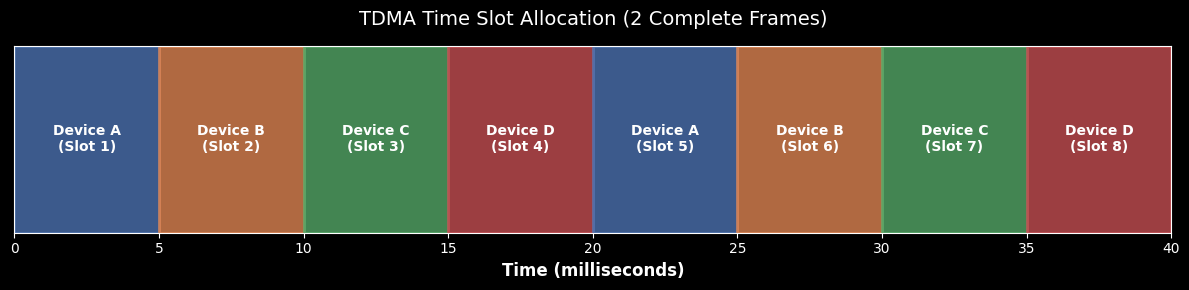

In [4]:
import matplotlib.pyplot as plt

# Set up the figure
fig, ax = plt.subplots(figsize=(12, 3))

# Devices and their assigned colors
devices = ['Device A', 'Device B', 'Device C', 'Device D']
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

# TDMA Frame parameters
time_slot_duration = 5 # milliseconds per slot
total_slots = 8 # Showing 2 complete frames (4 devices x 2)
current_time = 0

# Loop through the slots and assign them round-robin style
for slot in range(total_slots):
    device_idx = slot % len(devices)
    device = devices[device_idx]
    color = colors[device_idx]

    # Plot the time slot block (edgecolor adds a nice separator line between slots)
    ax.axvspan(current_time, current_time + time_slot_duration, color=color, alpha=0.8, edgecolor='white', linewidth=2)

    # Label the device inside the slot
    ax.text(current_time + (time_slot_duration / 2), 0.5, f"{device}\n(Slot {slot+1})",
            ha='center', va='center', color='white', fontweight='bold', fontsize=10)

    current_time += time_slot_duration

# Formatting the chart to look clean
ax.set_xlim(0, current_time)
ax.set_ylim(0, 1)
ax.set_yticks([]) # Hide the Y-axis since we only care about Time (X-axis)
ax.set_xlabel("Time (milliseconds)", fontsize=12, fontweight='bold')
ax.set_title("TDMA Time Slot Allocation (2 Complete Frames)", fontsize=14, pad=15)

# Display the timeline!
plt.tight_layout()
plt.show()

### 1.3 CDMA (Code Division Multiple Access) 🕵️‍♂️
CDMA allows everyone to transmit at the *exact same time* and on the *exact same frequency*. It works by assigning a unique, mathematically orthogonal code to each device.

CDMA relies on magic math: specifically, mathematical orthogonality. Every device has a unique code (like a signature). When these codes are multiplied and combined, they look like random noise. But when you multiply the combined signal by the *exact original signature* and average it out, your original signal pops right back out!

We'll visualize two orthogonal Walsh Codes (signatures) to see why they don't interfere.

Dot product of A and B: 0


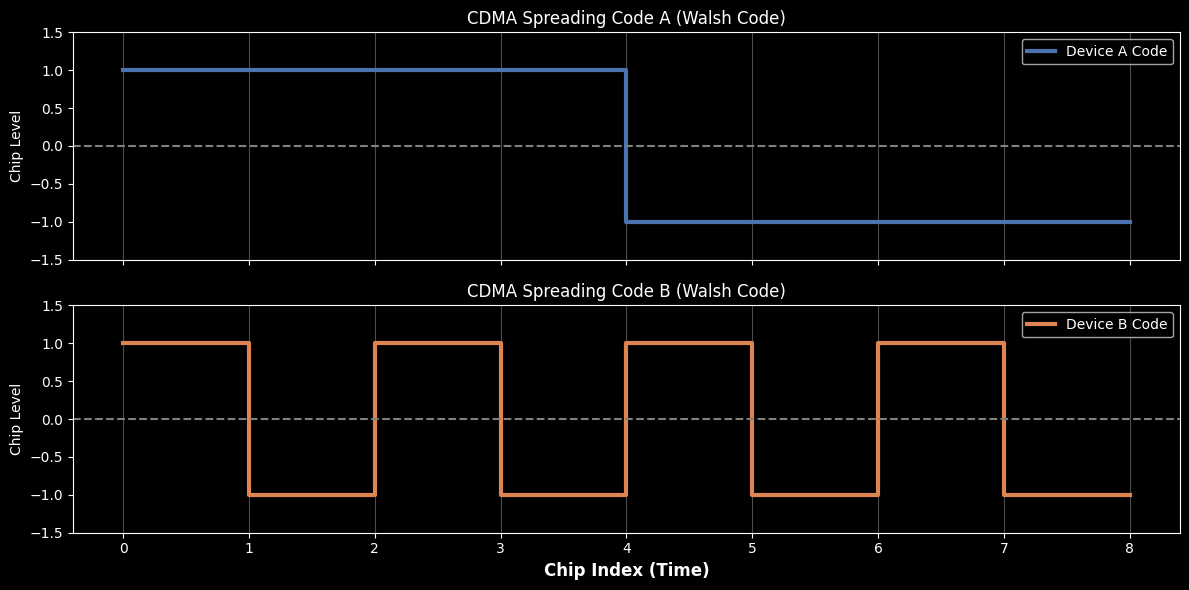

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipaddress
import random
import time

# --- CDMA Visualization: Orthogonal Walsh Codes ---

# Define two simple orthogonal spreading codes (Walsh codes)
code_length = 8
code_A = np.array([1, 1, 1, 1, -1, -1, -1, -1]) # Signature A
code_B = np.array([1, -1, 1, -1, 1, -1, 1, -1]) # Signature B

# Let's verify orthogonality visually (dot product should be zero)
print(f"Dot product of A and B: {np.dot(code_A, code_B)}")
# This should print 0!

# To plot them as step functions (like digital signals)
def make_step_signal(code):
    return np.repeat(code, 2), np.repeat(range(len(code)+1), 2)[1:-1]

sig_A_y, sig_A_x = make_step_signal(code_A)
sig_B_y, sig_B_x = make_step_signal(code_B)

# Set up the figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot Signature A
ax1.step(sig_A_x, sig_A_y, where='post', color='#4c72b0', linewidth=3, label="Device A Code")
ax1.set_ylabel("Chip Level", fontsize=10)
ax1.set_title("CDMA Spreading Code A (Walsh Code)", fontsize=12)
ax1.set_ylim(-1.5, 1.5)
ax1.axhline(0, color='gray', linestyle='--')
ax1.legend(loc='upper right')
ax1.grid(True, axis='x', alpha=0.3)

# Plot Signature B
ax2.step(sig_B_x, sig_B_y, where='post', color='#dd8452', linewidth=3, label="Device B Code")
ax2.set_xlabel("Chip Index (Time)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Chip Level", fontsize=10)
ax2.set_title("CDMA Spreading Code B (Walsh Code)", fontsize=12)
ax2.set_ylim(-1.5, 1.5)
ax2.axhline(0, color='gray', linestyle='--')
ax2.legend(loc='upper right')
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 1.3 CSMA (Carrier Sense Multiple Access) 🚦
CSMA is a "listen before you talk" protocol, commonly used in Ethernet (CSMA/CD) and Wi-Fi (CSMA/CA). If two devices sense the channel is clear and transmit simultaneously, a collision occurs.

When a collision is detected, devices stop transmitting, wait a random amount of time (using a **Binary Exponential Backoff** algorithm), and try again.

In CSMA/CA (Wi-Fi), devices use "Collision Avoidance" rather than detection. If the channel is busy *or* if a collision occurs, the device doesn't just wait a fixed time. It picks a *random* number of slots to wait from a specific window.

The clever part is **Binary Exponential Backoff**. If a device keeps failing, the range (window) of potential wait times doubles exponentially ($2^c - 1$). This rapidly increases the chances of choosing non-conflicting wait times, clearing congestion.

To truly understand Carrier Sense Multiple Access, we have to look at it over time.

Unlike TDMA where everyone has a polite, scheduled turn, CSMA is more like a crowded room where people just try to speak when it's quiet.
1. **Carrier Sense:** Devices listen to the cable. If it's idle, they transmit.
2. **Collision:** Because of propagation delay (the time it takes for an electrical signal to travel down the wire), two devices might sense the line is idle at the exact same moment and transmit together. Their signals crash into each other.
3. **Detection & Backoff:** The devices detect the voltage spike from the crash, send a "Jam Signal" to warn everyone else, and then start their random exponential backoff timers before trying again.

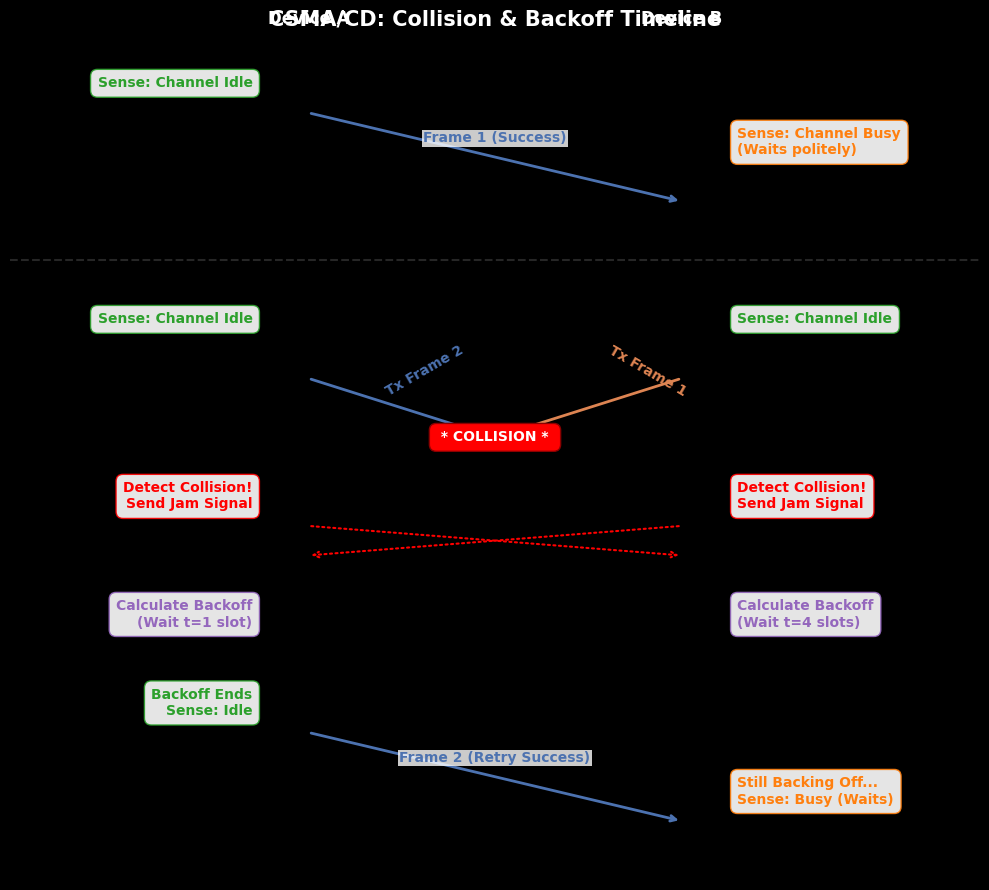

In [6]:
# --- CSMA Visualization: Sequence and Collision Chart ---
import matplotlib.pyplot as plt

def draw_csma_sequence():
    fig, ax = plt.subplots(figsize=(10, 9))
    ax.set_title("CSMA/CD: Collision & Backoff Timeline", fontsize=15, fontweight='bold', pad=20)

    # Give plenty of room on the sides for text boxes
    ax.set_xlim(-0.8, 1.8)
    ax.set_ylim(14, 0) # Invert Y axis so time goes down
    ax.axis('off')

    # Draw the device timelines
    ax.axvline(0, color='black', linewidth=2.5)
    ax.axvline(1, color='black', linewidth=2.5)
    ax.text(0, -0.5, 'Device A', ha='center', fontsize=12, fontweight='bold')
    ax.text(1, -0.5, 'Device B', ha='center', fontsize=12, fontweight='bold')

    # Helper function: Draw state/action boxes on the outside of the timelines
    def state(t, x, text, color='black'):
        x_pos = -0.15 if x == 0 else 1.15
        ha = 'right' if x == 0 else 'left'
        ax.text(x_pos, t, text, ha=ha, va='center', color=color, fontsize=10, fontweight='bold',
                bbox=dict(facecolor='white', edgecolor=color, alpha=0.9, boxstyle='round,pad=0.5'))

    # Helper function: Draw a successful transmission arrow
    def transmit(t1, t2, text, color):
        ax.annotate("", xy=(1, t2), xytext=(0, t1), arrowprops=dict(arrowstyle="->", color=color, lw=2))
        ax.text(0.5, (t1+t2)/2 - 0.25, text, ha='center', color=color, fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

    # Helper function: Draw signals crashing in the middle
    def collide(t_start, t_collide):
        # A transmits right, B transmits left
        ax.annotate("", xy=(0.5, t_collide), xytext=(0, t_start), arrowprops=dict(arrowstyle="-", color='#4c72b0', lw=2))
        ax.annotate("", xy=(0.5, t_collide), xytext=(1, t_start), arrowprops=dict(arrowstyle="-", color='#dd8452', lw=2))
        # The collision explosion box
        ax.text(0.5, t_collide, ' * COLLISION * ', ha='center', va='center', color='white', fontweight='bold',
                bbox=dict(facecolor='red', edgecolor='darkred', boxstyle='round,pad=0.5'))

    # --- Phase 1: Successful Transmission ---
    state(0.5, 0, 'Sense: Channel Idle', '#2ca02c')
    transmit(1, 2.5, 'Frame 1 (Success)', '#4c72b0')
    state(1.5, 1, 'Sense: Channel Busy\n(Waits politely)', '#ff7f0e')

    # Add a visual separator for the next scenario
    ax.axhline(3.5, color='gray', linestyle='--', alpha=0.3)

    # --- Phase 2: Simultaneous Transmission ---
    state(4.5, 0, 'Sense: Channel Idle', '#2ca02c')
    state(4.5, 1, 'Sense: Channel Idle', '#2ca02c')

    collide(5.5, 6.5)
    ax.text(0.2, 5.8, 'Tx Frame 2', color='#4c72b0', fontweight='bold', rotation=30)
    ax.text(0.8, 5.8, 'Tx Frame 1', color='#dd8452', fontweight='bold', rotation=-30)

    # --- Phase 3: Detection and Backoff ---
    state(7.5, 0, 'Detect Collision!\nSend Jam Signal', 'red')
    state(7.5, 1, 'Detect Collision!\nSend Jam Signal', 'red')

    # Draw crossed Jam signals
    ax.annotate("", xy=(1, 8.5), xytext=(0, 8), arrowprops=dict(arrowstyle="->", color='red', lw=1.5, ls=':'))
    ax.annotate("", xy=(0, 8.5), xytext=(1, 8), arrowprops=dict(arrowstyle="->", color='red', lw=1.5, ls=':'))

    state(9.5, 0, 'Calculate Backoff\n(Wait t=1 slot)', '#9467bd')
    state(9.5, 1, 'Calculate Backoff\n(Wait t=4 slots)', '#9467bd')

    # --- Phase 4: Recovery ---
    state(11, 0, 'Backoff Ends\nSense: Idle', '#2ca02c')
    transmit(11.5, 13, 'Frame 2 (Retry Success)', '#4c72b0')
    state(12.5, 1, 'Still Backing Off...\nSense: Busy (Waits)', '#ff7f0e')

    plt.tight_layout()
    plt.show()

# Run the visualization
draw_csma_sequence()

## 2. IPv4 Addressing and CIDR Notation 🌍
An IPv4 address is a 32-bit number. Instead of the old Class A/B/C system, we now use **CIDR (Classless Inter-Domain Routing)** to allocate IP addresses more efficiently.



The CIDR suffix (e.g., `/24`) tells us how many bits are locked for the network portion. The remaining bits are for the hosts.

To calculate the number of usable hosts in a subnet, we use the formula:
$$\text{Usable Hosts} = 2^{32 - \text{CIDR}} - 2$$
*(We subtract 2 for the Network and Broadcast addresses!)*

In [7]:
# Using Python's built-in ipaddress module to demonstrate CIDR math
import ipaddress

network_input = "192.168.10.0/26"
network = ipaddress.IPv4Network(network_input)

print(f"Analyzing Network: {network_input}")
print(f"Network Mask:      {network.netmask}")
print(f"Total IPs:         {network.num_addresses}")
print(f"Usable Hosts:      {network.num_addresses - 2}")
print(f"First Usable IP:   {list(network.hosts())[0]}")
print(f"Last Usable IP:    {list(network.hosts())[-1]}")
print(f"Broadcast Address: {network.broadcast_address}")

Analyzing Network: 192.168.10.0/26
Network Mask:      255.255.255.192
Total IPs:         64
Usable Hosts:      62
First Usable IP:   192.168.10.1
Last Usable IP:    192.168.10.62
Broadcast Address: 192.168.10.63


### 2.1 IPv4 Subnetting: Network vs. Host Bits 🌍
To understand CIDR, we need to look at the 32 bits of an IPv4 address. The **CIDR Mask** (like `/24`) is simply an integer that tells you how many leading bits are frozen as the **Network ID**. The remaining bits belong to the **Host ID**.

A visualization will instantly show you how changing the CIDR mask reshapes a subnet's capacity. We'll visualize standard subnets (`/24`) and more restrictive ones (`/28`).

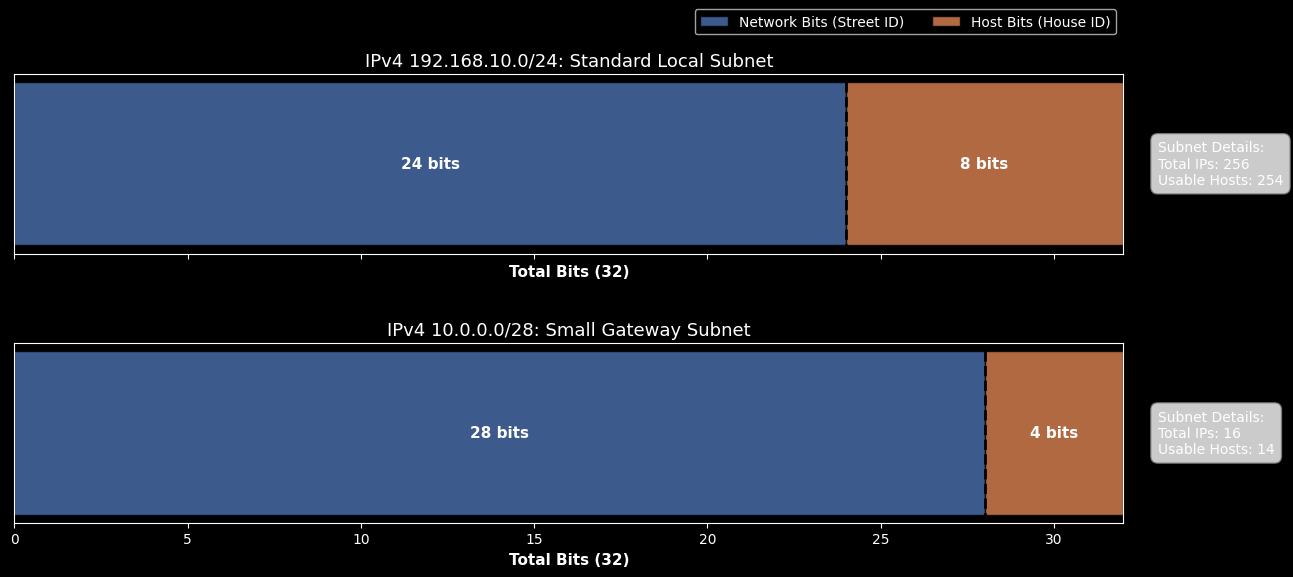

In [8]:
# --- IPv4/CIDR Visualization: Bitmask Breakdown ---

def plot_subnet_mask(cidr_mask, network_str, ax, title_suffix):
    """Plots the network vs. host bit breakdown for a CIDR mask."""
    network_bits = cidr_mask
    host_bits = 32 - cidr_mask

    # Analyze the network with ipaddress to get total IPs
    net_obj = ipaddress.IPv4Network(f"{network_str}/{cidr_mask}", strict=False)
    total_ips = net_obj.num_addresses

    # Create the stacked bar data
    ax.barh(0, network_bits, color='#4c72b0', alpha=0.8, edgecolor='black', label='Network Bits (Street ID)')
    ax.barh(0, host_bits, left=network_bits, color='#dd8452', alpha=0.8, edgecolor='black', label='Host Bits (House ID)')

    # Label the bits and the dividing line
    ax.text(network_bits/2, 0, f"{network_bits} bits", ha='center', va='center', color='white', fontweight='bold', fontsize=11)
    ax.text(network_bits + host_bits/2, 0, f"{host_bits} bits", ha='center', va='center', color='white', fontweight='bold', fontsize=11)
    ax.axvline(network_bits, color='black', linestyle='--', linewidth=2)
    ax.text(network_bits, 0.45, f"/{cidr_mask} Mask", ha='center', va='bottom', color='black', fontweight='bold')

    # Formatting and summary text
    ax.set_title(f"IPv4 {network_str}/{cidr_mask}: {title_suffix}", fontsize=13)
    ax.set_yticks([])
    ax.set_xlim(0, 32)
    ax.set_xlabel("Total Bits (32)", fontsize=11, fontweight='bold')

    summary_text = f"Subnet Details:\nTotal IPs: {total_ips}\nUsable Hosts: {total_ips - 2}"
    ax.text(33, 0, summary_text, va='center', ha='left', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))

# Setup the figure for comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# 1. Visualize a common /24 subnet (Standard local network)
plot_subnet_mask(24, "192.168.10.0", ax1, "Standard Local Subnet")
ax1.legend(loc='upper right', bbox_to_anchor=(1, 1.4), ncol=2)

# 2. Visualize a restrictive /28 subnet (Often used for specific IoT/gateway applications)
plot_subnet_mask(28, "10.0.0.0", ax2, "Small Gateway Subnet")

plt.tight_layout()
plt.subplots_adjust(hspace=0.5) # Add extra space between subplots
plt.show()

## 3. Transport Layer: TCP vs. UDP 🚚
The transport layer dictates *how* the data gets from point A to point B.



* **TCP (Transmission Control Protocol):** Connection-oriented. It guarantees delivery, checks for errors, and orders packets (like a registered letter). Slower, but highly reliable.
* **UDP (User Datagram Protocol):** Connectionless. It throws data at the destination as fast as possible without waiting for a receipt (like a live TV broadcast). Fast, but packet loss can happen.

### 3.1 Transport Layer: The Delivery Mechanics 📦
The transport layer dictates how data is managed between the source and destination.


* **TCP (Transmission Control Protocol):** Think of this like sending certified mail. The sender and receiver first establish a connection (the 3-way handshake). If a packet is lost along the way, the receiver doesn't acknowledge it, and the sender automatically retransmits it. It guarantees delivery and strict ordering.


* **UDP (User Datagram Protocol):** Think of this like a live sensor data stream or a live radio broadcast. The sender just blasts the data out as fast as possible. There is no handshake, no acknowledgments, and no retransmissions. If a packet drops, it's gone forever, but the overall stream never slows down.

In [9]:
# --- Transport Layer Demonstration: Console Simulation ---
import time
import random

def simulate_tcp():
    print("=== TCP Transmission Simulation ===")
    print("Sender: [SYN] -> Hello, can we talk?")
    time.sleep(1)
    print("Receiver: <- [SYN, ACK] Yes, I hear you. Can you hear me?")
    time.sleep(1)
    print("Sender: [ACK] -> Yes, connection established.\n")
    time.sleep(1)

    packets = ["Data 1", "Data 2", "Data 3"]
    for i, p in enumerate(packets):
        print(f"Sender: Sending [{p}] ->")
        time.sleep(0.5)
        # Simulate a 30% chance of packet loss on the 2nd packet
        if i == 1 and random.random() > 0.7:
            print("   ... ❌ Packet lost in transit!")
            time.sleep(1.5)
            print("Sender: Timeout! No ACK received. Retransmitting ->")
            print(f"Sender: Sending [{p}] (Retry) ->")
            time.sleep(0.5)

        print(f"Receiver: <- Received [{p}]. Sending [ACK]")
        time.sleep(0.5)
    print("Sender: [FIN] -> Closing connection.\n")

def simulate_udp():
    print("=== UDP Transmission Simulation ===")
    packets = ["Data 1", "Data 2", "Data 3", "Data 4"]
    for i, p in enumerate(packets):
        print(f"Sender: Blasting [{p}] ->")
        # Simulate a 25% chance of packet loss
        if random.random() > 0.75:
            print("   ... ❌ Packet dropped silently in transit.")
        else:
            print(f"Receiver: <- Received [{p}]")
        time.sleep(0.3) # Much faster, no waiting for ACKs!
    print("Sender: Transmission complete. (No connection to close)\n")

# Run the simulations (Try running this cell multiple times to see the random packet loss!)
simulate_tcp()
simulate_udp()

=== TCP Transmission Simulation ===
Sender: [SYN] -> Hello, can we talk?
Receiver: <- [SYN, ACK] Yes, I hear you. Can you hear me?
Sender: [ACK] -> Yes, connection established.

Sender: Sending [Data 1] ->
Receiver: <- Received [Data 1]. Sending [ACK]
Sender: Sending [Data 2] ->
   ... ❌ Packet lost in transit!
Sender: Timeout! No ACK received. Retransmitting ->
Sender: Sending [Data 2] (Retry) ->
Receiver: <- Received [Data 2]. Sending [ACK]
Sender: Sending [Data 3] ->
Receiver: <- Received [Data 3]. Sending [ACK]
Sender: [FIN] -> Closing connection.

=== UDP Transmission Simulation ===
Sender: Blasting [Data 1] ->
Receiver: <- Received [Data 1]
Sender: Blasting [Data 2] ->
   ... ❌ Packet dropped silently in transit.
Sender: Blasting [Data 3] ->
   ... ❌ Packet dropped silently in transit.
Sender: Blasting [Data 4] ->
Receiver: <- Received [Data 4]
Sender: Transmission complete. (No connection to close)



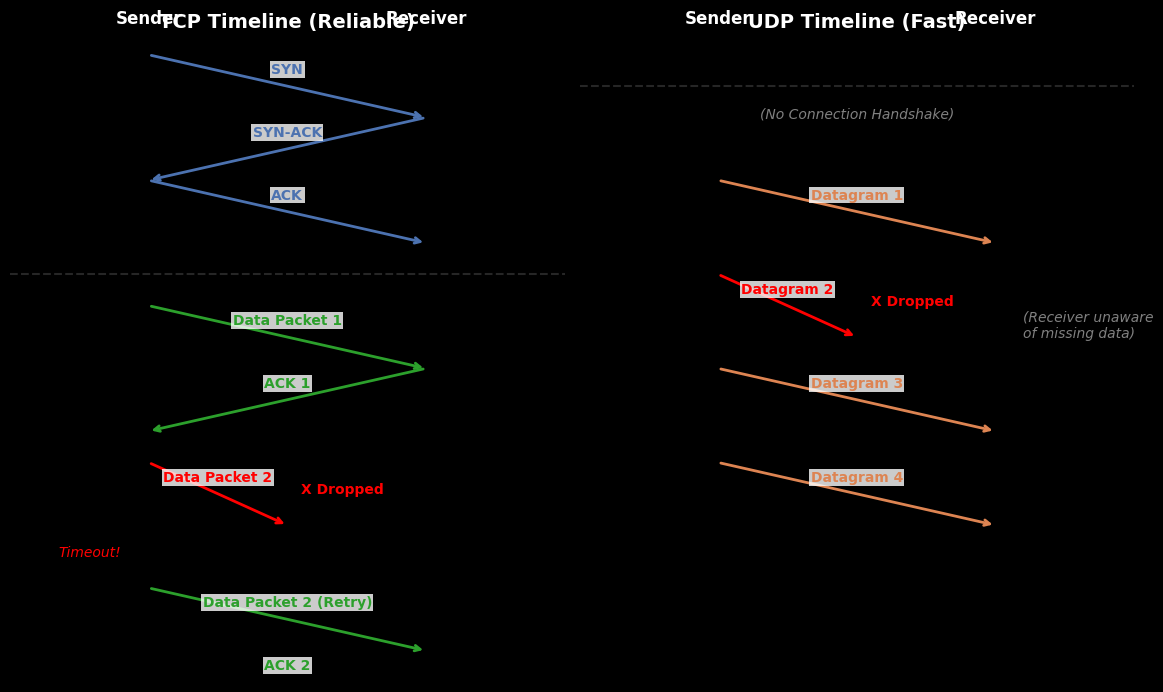

In [10]:
# --- Transport Layer Visualization: Message Sequence Chart ---
import matplotlib.pyplot as plt

def draw_sequence(ax, title, protocol):
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(10, 0) # Invert Y axis so time goes down
    ax.axis('off')

    # Draw Sender and Receiver timelines
    ax.axvline(0, color='black', linewidth=2)
    ax.axvline(1, color='black', linewidth=2)
    ax.text(0, -0.5, 'Sender', ha='center', fontsize=12, fontweight='bold')
    ax.text(1, -0.5, 'Receiver', ha='center', fontsize=12, fontweight='bold')

    # Helper function to draw message arrows
    def msg(t1, t2, text, color, lost=False, right_to_left=False):
        x_start, x_end = (1, 0) if right_to_left else (0, 1)
        if lost:
            x_end = 0.5 # Stop halfway
            # FIXED LINE: Removed the emoji and replaced it with a standard "X"
            ax.text(0.55, (t1+t2)/2, 'X Dropped', color='red', fontsize=10, fontweight='bold')

        ax.annotate("", xy=(x_end, t2), xytext=(x_start, t1),
                    arrowprops=dict(arrowstyle="->", color=color, lw=2))

        # Label placement
        text_x = 0.5 if not lost else 0.25
        ax.text(text_x, (t1+t2)/2 - 0.2, text, ha='center', color=color, fontsize=10, fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

    # Draw the specific protocol sequence
    if protocol == 'TCP':
        # Handshake
        msg(0, 1, 'SYN', '#4c72b0')
        msg(1, 2, 'SYN-ACK', '#4c72b0', right_to_left=True)
        msg(2, 3, 'ACK', '#4c72b0')
        ax.axhline(3.5, color='gray', linestyle='--', alpha=0.3) # Separator
        # Data Transfer
        msg(4, 5, 'Data Packet 1', '#2ca02c')
        msg(5, 6, 'ACK 1', '#2ca02c', right_to_left=True)
        # Packet Loss Simulation
        msg(6.5, 7.5, 'Data Packet 2', 'red', lost=True)
        ax.text(-0.1, 8, 'Timeout!', ha='right', color='red', style='italic')
        msg(8.5, 9.5, 'Data Packet 2 (Retry)', '#2ca02c')
        msg(9.5, 10.5, 'ACK 2', '#2ca02c', right_to_left=True)

    elif protocol == 'UDP':
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3) # No Handshake
        ax.text(0.5, 1, '(No Connection Handshake)', ha='center', style='italic', color='gray')
        # Data Transfer
        msg(2, 3, 'Datagram 1', '#dd8452')
        msg(3.5, 4.5, 'Datagram 2', 'red', lost=True)
        msg(5, 6, 'Datagram 3', '#dd8452')
        msg(6.5, 7.5, 'Datagram 4', '#dd8452')
        ax.text(1.1, 4.5, '(Receiver unaware\nof missing data)', ha='left', color='gray', style='italic')

# Create the figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))

draw_sequence(ax1, "TCP Timeline (Reliable)", 'TCP')
draw_sequence(ax2, "UDP Timeline (Fast)", 'UDP')

plt.tight_layout()
plt.show()